In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/anime.csv')

"Executive Summary"


"يهدف هذا المشروع الي استكشاف تفضيلات جمهور الأنمي من خلال تحليل بيانات اكثر من 12ألف عمل والبحث في مدي تأثير طول العمل ونوعه علي تقييمه النهائي"

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_12395/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
Report=ProfileReport(df,title='Anime Report',explorative=True)

In [ ]:
Report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00,  8.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df.shape

(12294, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


Data Cleaning

In [ ]:
df.isna().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [ ]:
df['genre'].fillna(df['genre'].mode()[0],inplace=True)

/tmp/ipykernel_12395/2221661984.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genre'].fillna(df['genre'].mode()[0],inplace=True)


In [ ]:
df['type'].fillna(df['type'].mode()[0],inplace=True)

/tmp/ipykernel_12395/1828210288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['type'].fillna(df['type'].mode()[0],inplace=True)


In [ ]:
df['rating'].fillna(df['rating'].mean(),inplace=True)

/tmp/ipykernel_12395/3424798236.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].mean(),inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head(5)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


EDA

In [ ]:
df.describe()

,anime_id,rating,members
count,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.017096,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.900000,2.250000e+02
50%,10260.500000,6.550000,1.550000e+03
75%,24794.500000,7.170000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

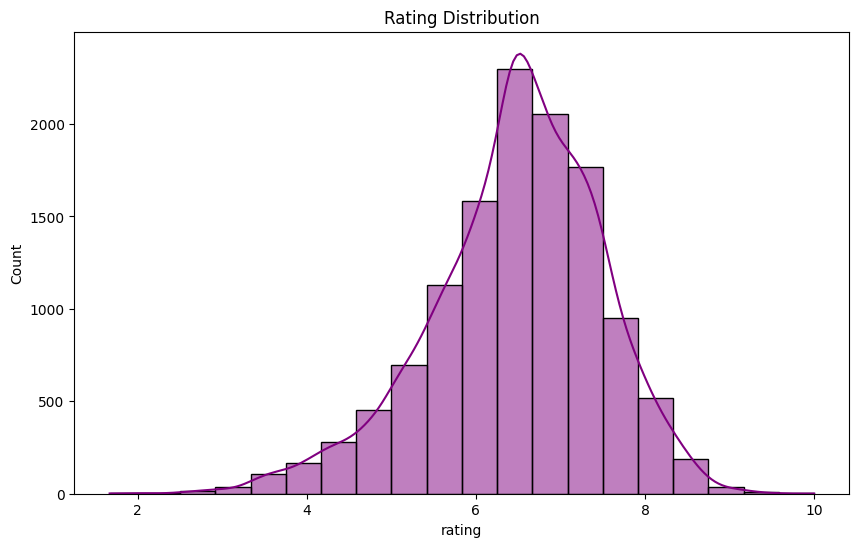

In [47]:
plt.figure(figsize=(10,6))
sns.histplot(df['rating'],bins=20,kde=True,color='purple')
plt.title('Rating Distribution')
plt.show()

<div dir="rtl">


الملاحظة : يظهر الرسم البياني ان معظم تقييمات الانمي تتركز في النطاق بين 6 و 8  درجات مع وجود عدد قليل جداً من الاعمال التي تكسر حاجز ال9 او تنخفض تحت ال4


الاستنتاج : هذا يشير الي ان المعايير التي يضعها الجمهور تميل للاعتدال وان الوصول لتقييم مرتفع جداً هو استثناء يعكس جودة غير عادية للعمل

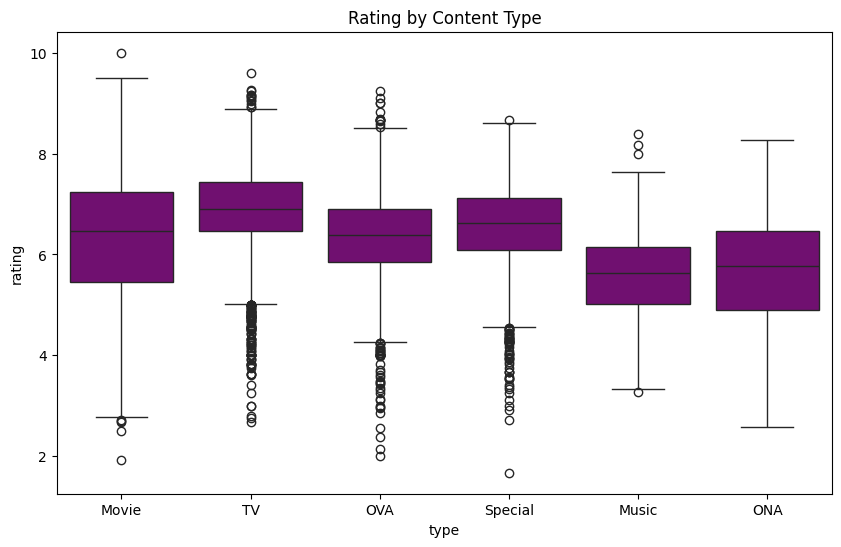

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='type',y='rating',color='purple')
plt.title('Rating by Content Type')
plt.show()

<div dir="rtl">




الملاحظة: نلاحظ من خلال ال boxplot ان متوسط تقسسمات الافلام (Movies) يميل لأن يكون اعلي قليلاُ وبشكل اكثر استقراراً من المسلسلات التلفزيونية (TV)
الاستنتاج: قد يرجع ذلك الي ان الافلام تحظي بميزانيات انتاج اعلي وجودة بصرية افضل كما انها لا تعاني من مشاكل "التمطيط" التي قد تظهر في المسلسلات الطويلة مما يرفع من قيمتها لدي المشاهد

In [ ]:
q1=df['rating'].quantile(0.25)
q3=df['rating'].quantile(0.75)
iqr=q3-q1

In [ ]:
q3

np.float64(7.17)

In [ ]:
q1

np.float64(5.9)

In [ ]:
iqr

np.float64(1.2699999999999996)

In [ ]:
upper_rating=q3+1.5*iqr
lower_rating=q1-1.5*iqr

In [ ]:
upper_rating

np.float64(9.075)

In [ ]:
lower_rating

np.float64(3.995000000000001)

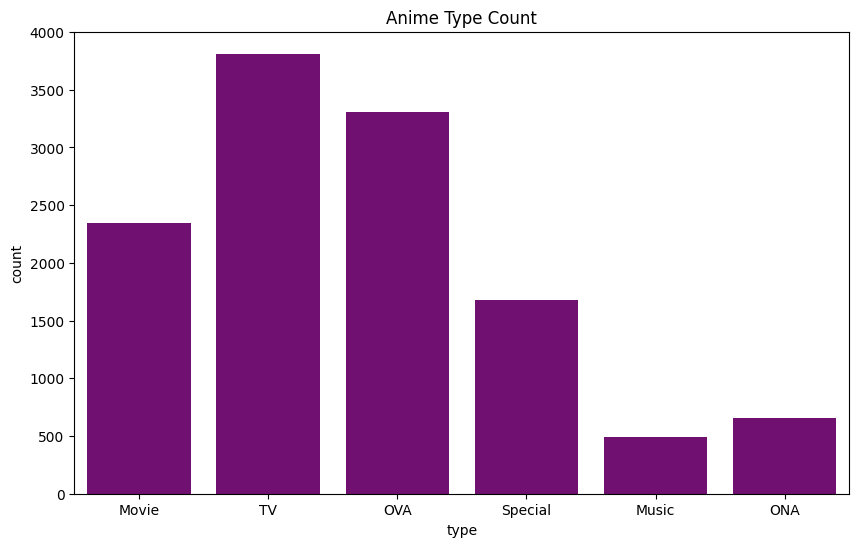

In [49]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='type',color='purple')
plt.title('Anime Type Count')
plt.show()

In [ ]:
df['genre'].value_counts()

,count
genre,
Hentai,885
Comedy,523
Music,301
Kids,199
"Comedy, Slice of Life",179
...,...
"Hentai, Parody, Sci-Fi",1
"Hentai, Historical, Mystery",1
"Action, Comedy, Hentai",1


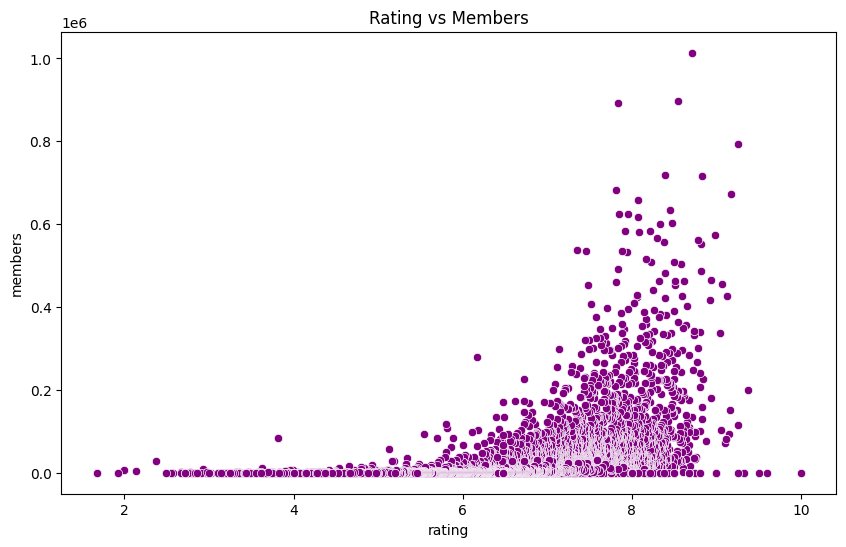

In [50]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='rating',y='members',color='purple')
plt.title('Rating vs Members')
plt.show()

<div dir="rtl">


الملاحظة : هناك علاقة طردية واضحة كلما زاد عدد المشتركين (Members) في الانمي زاد تقيمه بشكل عام


الاستنتاج : الاعمال الاكثر شعبية تميل دائماً لحصد تقيمات مرتفعة مما يعني ان "شهرة" العمل تلعب دوراً كبيرً في تقيمه النهائي وان الجودة العالية للعمل هي التي تجذب عدداً امبر من الناس للمشاهدة والتقييم

In [ ]:
df['episodes'].value_counts()

,count
episodes,
1,5677
2,1076
12,816
13,572
26,514
...,...
1006,1
162,1
132,1


In [ ]:
df['episodes_numeric'] = pd.to_numeric(df['episodes'], errors='coerce')
bins = [0, 1, 13, 26, 52, 100, float('inf')]
labels = ['Movie(1)','Short(2-13)','Standard(14-26)','Medium(27-52)','Long(53-100)','Soper Long(100+)']
df['episode_category'] = pd.cut(df['episodes_numeric'], bins=bins, labels=labels, right=True)

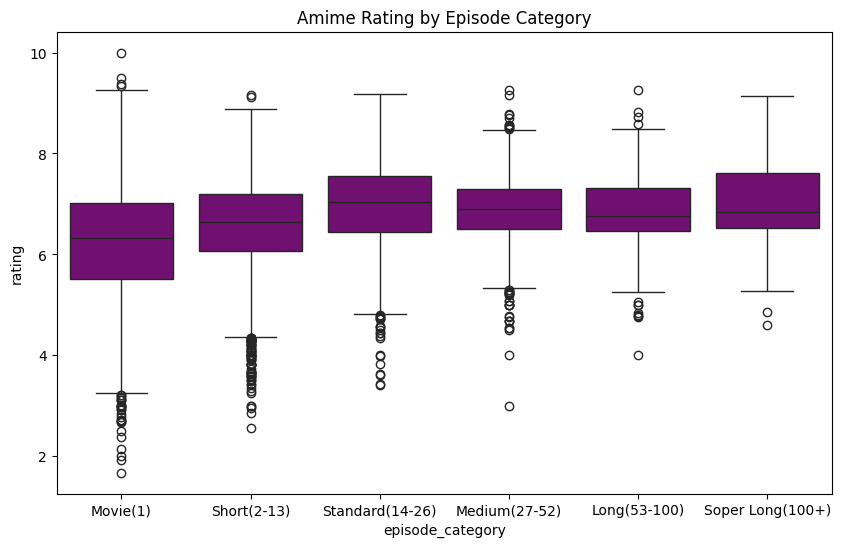

In [51]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='episode_category',y='rating',color='purple')
plt.title('Amime Rating by Episode Category')
plt.show()

الملاحظة<div dir="rtl">
: بعد تقسيم الانمي لفئات يظهر بوضوح ان الانميات الطويلة جد
(Super Long) تمتلاك متوسط تقيم مرتفع بينما الانميات القصيرة (Short) لديها تشتت كبير في التقيمات


الاستنتاج : هذا يعكس "فلترة" طبيعية فالاعمال التي لا تحقق نجاحاً يتم ايقافها مبكراً (فتظهر بتقييم منخفض في الفئات القصيرة ) أما الاعمال التي تستمر لمئات الحلقات فهي بالضرورة اعمال ناجحة ولديها قاعدة جماهيرية كبيرة تنحها تقييمات عالية

In [ ]:
print(df['episode_category'].value_counts())

episode_category
Movie(1)            5677
Short(2-13)         4043
Standard(14-26)     1089
Medium(27-52)        803
Long(53-100)         183
Soper Long(100+)     159
Name: count, dtype: int64


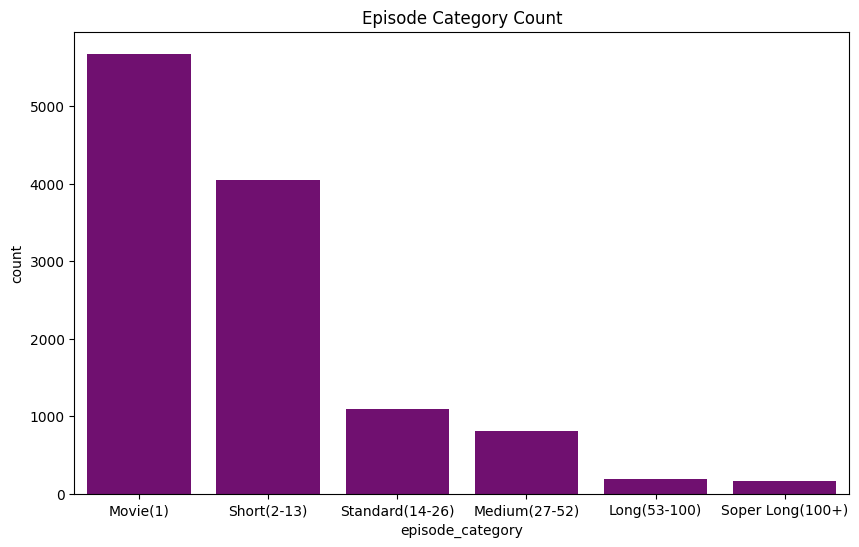

In [54]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='episode_category',color='purple')
plt.title('Episode Category Count')
plt.show()

In [ ]:
from collections import Counter
genres_list=df['genre'].str.split(',').dropna()
all_genres=[genres for sublist in genres_list for genres in sublist]
genre_counts=Counter(all_genres)
top_genres=pd.DataFrame(genre_counts.most_common(10),columns=['Genre','Count'])

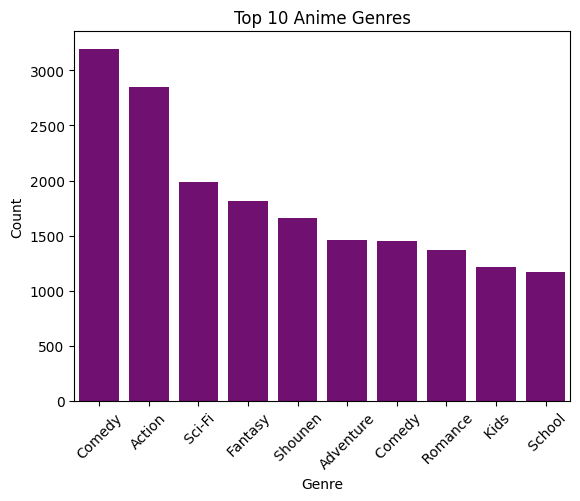

In [55]:
sns.barplot(data=top_genres,x='Genre',y='Count',color='purple')
plt.title('Top 10 Anime Genres')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from wordcloud import WordCloud,ImageColorGenerator
import numpy as np
import PIL.Image

In [ ]:
text=" ".join(df['genre'])

In [ ]:
text

'Drama, Romance, School, Supernatural Action, Adventure, Drama, Fantasy, Magic, Military, Shounen Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen Sci-Fi, Thriller Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen Comedy, Drama, School, Shounen, Sports Action, Adventure, Shounen, Super Power Drama, Military, Sci-Fi, Space Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen Drama, Fantasy, Romance, Slice of Life, Supernatural Drama, School, Shounen Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen Action, Drama, Mecha, Military, Sci-Fi, Super Power Comedy, Drama, School, Shounen, Sports Adventure, Drama, Supernatural Drama, Music, Romance, School, Shounen Adventure, Fantasy, Historical, Mystery, Seinen, Slice of Life, Supernatural Fantasy, Slice of Life Action, Mecha, Military, School, Sci-Fi, Super Power Comedy, Drama, Shounen, Sports Action, Drama, Historical, Martial Arts, Romance,

In [ ]:
wcloud=WordCloud(background_color='white',colormap='cool',contour_color='black',height=800,width=1600,contour_width=3,min_font_size=3,scale=2).generate(text)

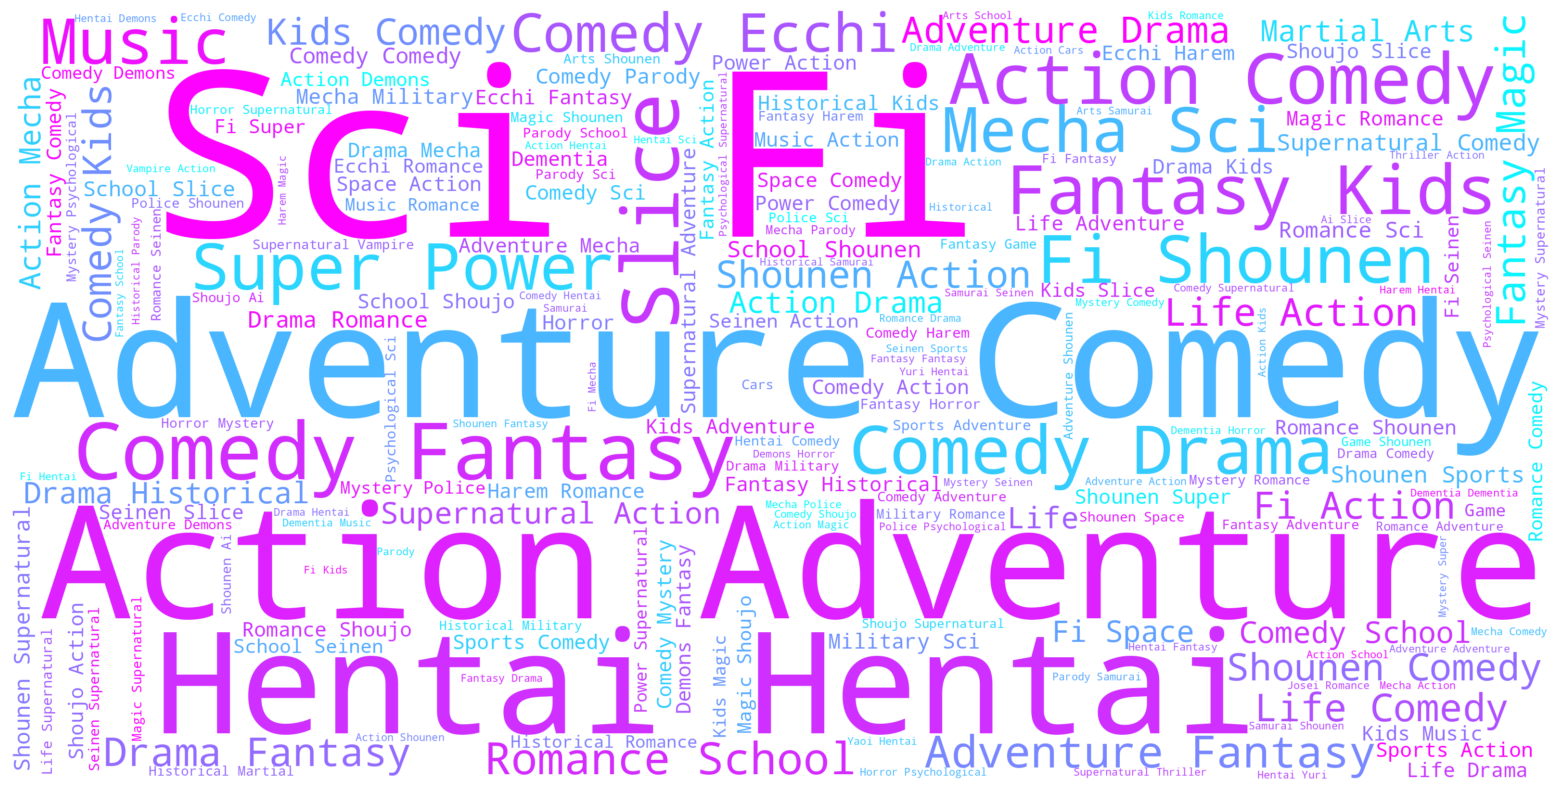

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(wcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

<div dir="rtl">



الملاحظة : الكلمات الاكثر بروزاً الWordcloud مثل (Comedy , Action , Sci-Fi) توضح التوجهات السائدة في صناعة الانمي



الاستنتاج : نجد ان تصنيف الاكشن و الكوميديا هما المسيطران علي اغلب الانتاجات مما يعكس ذوق الجمهور العالمي الذي يميل للاعمال التي تحتوي علي مزيج من الاثارة و الترفيه